# ANN and MLP Architecture: Code Companion

Optional background: [notes](04_ANN_and_MLP_Architecture_Notes.ipynb). A multilayer perceptron (MLP) is a feedforward chain of dense layers and nonlinear activations. We will build a 2 → 3 → 2 → 1 MLP, verify its worked example, trace a batch through the layers, and compare architecture sizes and output heads.

Use the [README setup](README.md) and run all cells from a fresh kernel. This notebook uses Python, PyTorch, NumPy, and Matplotlib on CPU. Parameters are hand-set or seeded; no data downloads, model training, or performance evaluation occur. No data split is needed for inspecting these fixed computations.

## Start with the problem this lesson solves

A greenhouse decision may depend on several combinations of dryness and warmth, rather than one weighted total. A multilayer perceptron (MLP) places several neurons in a layer, then lets another layer combine their responses. An MLP is one kind of ANN.

An architecture specifies how many intermediate values are computed and how they connect. It creates room to learn useful combinations; choosing a larger architecture alone does not teach anything. We first inspect fixed weights so every hidden value has an explainable origin.

## Trace the complete 2 → 3 → 2 → 1 calculation

Use $x=[0.8,0.4]$. The first layer has three neurons with weight rows $[1,1]$, $[1,-1]$, and $[-1,1]$, and biases $[0,-0.5,0.25]$.

| First neuron | Weighted sum plus bias | After ReLU |
| --- | --- | --- |
| A | $0.8(1)+0.4(1)+0=1.2$ | 1.2 |
| B | $0.8(1)+0.4(-1)-0.5=-0.1$ | 0 |
| C | $0.8(-1)+0.4(1)+0.25=-0.15$ | 0 |

Thus the first representation is $h=[1.2,0,0]$. A combines readings; B and C compare them in different directions. These interpretations follow from the chosen weights, not from neuron names supplied to the model.

The second layer has two weight rows $[1,-1,0.5]$ and $[0.5,1,-1]$, with biases $[-0.2,0.1]$:

$$g_1=\max(0,1.2(1)+0(-1)+0(0.5)-0.2)=1.0,$$
$$g_2=\max(0,1.2(0.5)+0(1)+0(-1)+0.1)=0.7.$$

The last neuron uses weights $[2,-1]$ and bias $-0.5$:

$$z=1.0(2)+0.7(-1)-0.5=0.8.$$

This is the complete forward pass: two measurements become three features, then two features, then one score. A binary-probability interpretation would apply sigmoid, $1/(1+e^{-0.8})\approx0.689974$. The inspected model itself returns the raw score; it has not been trained as a calibrated classifier.

**Account for every adjustable number.** Layer one has $3\times2=6$ weights and three biases: nine parameters. Layer two has $2\times3=6$ weights and two biases: eight. The output has two weights and one bias: three. Total $9+8+3=20$. ReLU stores no adjustable weight. Sending seven examples through this model reuses these same 20 parameters; it does not create seven separate networks.

## Why use layers instead of one large sum?

Each nonlinear layer can reorganize information for the next. The network is useful when such learned combinations support predictions better than the original features alone. Backpropagation later adjusts every layer according to its effect on the final error; hidden layers usually do not receive their own hand-written targets.

Width gives a layer more intermediate values. Depth adds successive transformations. Both affect capacity and cost, and either can increase overfitting. Without nonlinear activations, the entire chain would reduce to a single affine map. The arithmetic above demonstrates the architecture, not an empirical advantage over a smaller model.

## Connect the explanation to the code

Each `nn.Linear(in_features, out_features)` stores an `out_features × in_features` weight matrix plus one bias per output. In `forward`, each returned tensor becomes the next layer's input. `nn.Sequential` expresses the same ordered operations. `state_dict` contains the learned numbers, while the class or sequential definition specifies how those numbers are used.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| NumPy:", np.__version__)
print("CPU | architecture inspection, no training")

Python: 3.9.6
PyTorch: 2.2.2 | NumPy: 1.26.4
CPU | architecture inspection, no training


## Start with the smallest chain

A dense layer produces two hidden values from two inputs. ReLU transforms them, and a final layer produces one score. This first miniature example shows how `nn.Sequential` connects modules; its random output has no predictive meaning. Notice that activations appear explicitly between dense layers.

In [2]:
small_model = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1))
example = torch.tensor([[0.8, 0.4]])
print(small_model)
with torch.no_grad():
    print("Input shape:", tuple(example.shape), "-> output shape:", tuple(small_model(example).shape))
print("Parameters:", sum(p.numel() for p in small_model.parameters()))

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)
Input shape: (1, 2) -> output shape: (1, 1)
Parameters: 9


## Name the layers in the worked architecture

`nn.Module` registers layers assigned to it so PyTorch can find their parameters. `forward` defines the computation path. Each hidden layer has its own weights and bias, while ReLU has no parameters. The output layer returns a raw score.

We then overwrite the initial random parameters with the exact values from the notes. These assignments are deliberate arithmetic setup, not training.

In [3]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 3)
        self.hidden2 = nn.Linear(3, 2)
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        h = torch.relu(self.hidden1(x))
        g = torch.relu(self.hidden2(h))
        return self.output(g)

model = TinyMLP()
with torch.no_grad():
    model.hidden1.weight.copy_(torch.tensor([[1., 1.], [1., -1.], [-1., 1.]]))
    model.hidden1.bias.copy_(torch.tensor([0., -0.5, 0.25]))
    model.hidden2.weight.copy_(torch.tensor([[1., -1., 0.5], [0.5, 1., -1.]]))
    model.hidden2.bias.copy_(torch.tensor([-0.2, 0.1]))
    model.output.weight.copy_(torch.tensor([[2., -1.]]))
    model.output.bias.copy_(torch.tensor([-0.5]))
print(model)

TinyMLP(
  (hidden1): Linear(in_features=2, out_features=3, bias=True)
  (hidden2): Linear(in_features=3, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=1, bias=True)
)


## Verify the actual numbers, not only the dimensions

For one example, the first hidden outputs should be `(1.2, 0, 0)`, the second should be `(1.0, 0.7)`, and the final score should be `0.8`. Printing pre-activation values shows what ReLU removes. Assertions allow small floating-point rounding differences.

In [4]:
with torch.no_grad():
    first_scores = model.hidden1(example)
    h = torch.relu(first_scores)
    second_scores = model.hidden2(h)
    g = torch.relu(second_scores)
    score = model(example)
for name, values in [("First scores", first_scores), ("First hidden", h),
                     ("Second scores", second_scores), ("Second hidden", g), ("Output score", score)]:
    print(f"{name:15s}: {np.round(values.numpy(), 3)}")
torch.testing.assert_close(h, torch.tensor([[1.2, 0., 0.]]))
torch.testing.assert_close(g, torch.tensor([[1., 0.7]]))
torch.testing.assert_close(score, torch.tensor([[0.8]]))

First scores   : [[ 1.2  -0.1  -0.15]]
First hidden   : [[1.2 0.  0. ]]
Second scores  : [[1.  0.7]]
Second hidden  : [[1.  0.7]]
Output score   : [[0.8]]


## Trace a batch and inspect the parameter budget

Four sensor pairs form a batch of shape `(4, 2)`. The layers change feature width, while the batch axis stays four. We run the named layers explicitly to reveal intermediate values; the final result must match `model(X)`.

Parameter counting includes every stored weight and bias regardless of whether it currently equals zero. These 20 float32 values occupy 80 bytes of numerical storage, excluding framework overhead and all other tensors.

In [5]:
X = torch.tensor([[0.8, 0.4], [0.2, 0.4], [0.5, 0.5], [0.9, 0.9]])
with torch.no_grad():
    values = X
    print("Input:", tuple(values.shape))
    for name, layer in [("Hidden 1 affine", model.hidden1), ("ReLU 1", nn.ReLU()),
                        ("Hidden 2 affine", model.hidden2), ("ReLU 2", nn.ReLU()),
                        ("Output affine", model.output)]:
        values = layer(values)
        print(f"{name:17s} -> {tuple(values.shape)}")
    torch.testing.assert_close(values, model(X))

print("\nParameter tensors:")
for name, parameter in model.named_parameters():
    print(f"{name:20s} shape={str(tuple(parameter.shape)):8s} count={parameter.numel()}")
parameter_count = sum(p.numel() for p in model.parameters())
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
print(f"Total: {parameter_count} parameters; {parameter_bytes} bytes of parameter data")
assert parameter_count == 20
assert parameter_bytes == 80

Input: (4, 2)
Hidden 1 affine   -> (4, 3)
ReLU 1            -> (4, 3)
Hidden 2 affine   -> (4, 2)
ReLU 2            -> (4, 2)
Output affine     -> (4, 1)

Parameter tensors:
hidden1.weight       shape=(3, 2)   count=6
hidden1.bias         shape=(3,)     count=3
hidden2.weight       shape=(2, 3)   count=6
hidden2.bias         shape=(2,)     count=2
output.weight        shape=(1, 2)   count=2
output.bias          shape=(1,)     count=1
Total: 20 parameters; 80 bytes of parameter data


## Batch size changes the work, not the model

Repeating one example seven times creates seven independent rows. Each uses the same weights, so each gets the same output. The current model contains no operations that mix batch rows. Model parameter storage stays fixed, although larger batches need more space for inputs and intermediate values.

In [6]:
with torch.no_grad():
    repeated = example.repeat(7, 1)
    repeated_scores = model(repeated)
    torch.testing.assert_close(repeated_scores, score.expand(7, 1))
print("Input shape:", tuple(repeated.shape), "| output shape:", tuple(repeated_scores.shape))
print("Repeated scores:", np.round(repeated_scores.numpy().ravel(), 3))
print("Parameter count is still:", sum(p.numel() for p in model.parameters()))

Input shape: (7, 2) | output shape: (7, 1)
Repeated scores: [0.8 0.8 0.8 0.8 0.8 0.8 0.8]
Parameter count is still: 20


## Two coding styles, the same architecture and values

Create a separate `nn.Sequential` chain with matching dimensions. Copy each dense layer's state—the weights and biases—into the corresponding layer. Matching architecture alone would not imply matching outputs: random initial parameters usually differ. Copying values makes this a meaningful equivalence check.

The two models have separate parameter storage; subsequent edits to one model will not automatically edit the other.

In [7]:
sequential = nn.Sequential(
    nn.Linear(2, 3), nn.ReLU(),
    nn.Linear(3, 2), nn.ReLU(),
    nn.Linear(2, 1),
)
for destination, source in [(sequential[0], model.hidden1),
                            (sequential[2], model.hidden2),
                            (sequential[4], model.output)]:
    destination.load_state_dict(source.state_dict())
    assert destination.weight.data_ptr() != source.weight.data_ptr()
with torch.no_grad():
    torch.testing.assert_close(sequential(X), model(X))
print("Sequential and named-layer outputs match on all four examples.")

Sequential and named-layer outputs match on all four examples.


## Compare width and depth without claiming a winner

The helper below builds an MLP from a list of layer sizes, inserting ReLU after each hidden layer and leaving the output raw. It does not choose an architecture for us. We compare parameter counts, not predictive accuracy. A larger count means more adjustable values, not necessarily better generalization.

2 → 1               | hidden layers 0 | parameters 3
2 → 4 → 1           | hidden layers 1 | parameters 17
2 → 8 → 1           | hidden layers 1 | parameters 33
2 → 4 → 4 → 1       | hidden layers 2 | parameters 37


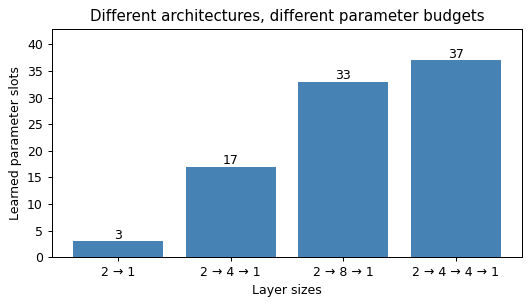

In [8]:
def build_mlp(sizes):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)

architectures = [[2, 1], [2, 4, 1], [2, 8, 1], [2, 4, 4, 1]]
labels, counts = [], []
for sizes in architectures:
    candidate = build_mlp(sizes)
    count = sum(p.numel() for p in candidate.parameters())
    formula_count = sum((m + 1) * n for m, n in zip(sizes[:-1], sizes[1:]))
    assert count == formula_count
    label = " → ".join(map(str, sizes))
    labels.append(label)
    counts.append(count)
    print(f"{label:19s} | hidden layers {len(sizes) - 2} | parameters {count}")
assert counts == [3, 17, 33, 37]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(labels, counts, color="steelblue")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 0.5, str(count), ha="center")
ax.set(ylabel="Learned parameter slots", xlabel="Layer sizes", title="Different architectures, different parameter budgets", ylim=(0, 43))
plt.tight_layout()
plt.show()

## Attach output heads that match different tasks

The last hidden representation has two values per example. A `Linear(2, 1)` head returns one value, while `Linear(2, 3)` returns three. Either could be useful in an appropriately trained model, depending on the target and loss.

Here the heads are untrained and we inspect only shapes. A `(batch, 3)` output alone does not tell us whether the values mean competing classes, independent labels, or three regression quantities. The task determines that interpretation.

In [9]:
one_value_head = nn.Linear(2, 1)
three_value_head = nn.Linear(2, 3)
with torch.no_grad():
    representation = torch.relu(model.hidden2(torch.relu(model.hidden1(X))))
    one_value = one_value_head(representation)
    three_values = three_value_head(representation)
print("Shared representation:", tuple(representation.shape))
print("One-value output:", tuple(one_value.shape))
print("Three-value output:", tuple(three_values.shape))
print("Head parameter counts:", sum(p.numel() for p in one_value_head.parameters()),
      "and", sum(p.numel() for p in three_value_head.parameters()))
assert one_value.shape == (4, 1)
assert three_values.shape == (4, 3)

Shared representation: (4, 2)
One-value output: (4, 1)
Three-value output: (4, 3)
Head parameter counts: 3 and 9


## What the inspection establishes

The architecture fixes connections, widths, depth, and output shape. Numerical parameters determine the function within that design. The worked example matches the notes, both coding styles compute the same result after copying parameters, and changing batch size does not change parameter count.

We have not trained a predictor, compared accuracy, or established that any architecture is best. A real comparison would fit parameters on training data, select architecture using validation data, and evaluate the final choice on held-out test data.

In [ ]:
torch.manual_seed(4)
inputs = torch.tensor([[1., 2.], [2., -1.]])
targets = torch.tensor([[1.], [-1.]])
for zero in [True, False]:
    model = nn.Sequential(nn.Linear(2, 3), nn.Tanh(), nn.Linear(3, 1))
    for layer in [model[0], model[2]]:
        nn.init.zeros_(layer.bias)
        (nn.init.zeros_ if zero else nn.init.xavier_normal_)(layer.weight)
    (model(inputs) - targets).square().mean().backward()
    print('zero weights' if zero else 'Xavier weights', model[0].weight.grad.norm().item())
    if zero: assert model[0].weight.grad.norm() == 0

bn = nn.BatchNorm1d(2, affine=False, momentum=1.)
ln = nn.LayerNorm(2, elementwise_affine=False)
table = torch.tensor([[1., 2.], [3., 6.]])
bn.train(); train_bn = bn(table); ln_values = ln(table)
bn.eval(); eval_bn = bn(table)
assert not torch.allclose(train_bn, eval_bn)
assert torch.allclose(ln_values, torch.cat([ln(row[None]) for row in table]))
print('BatchNorm train/eval differ; LayerNorm is per example')